#### In this notebook, I am going to run Logistic Regression, RandomForestClassifier and Xgboost to predict WineQuality
##### I have taken the WineQT dataset from kaggle to perform these operations on  

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,precision_score,f1_score,recall_score

In [2]:
wineqt=pd.read_csv("WineQT.csv",low_memory=False)
wineqt.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
X = wineqt.iloc[:,:-2]
y = wineqt.iloc[:,-2] - 3

#### We will check if there are any values that are missing

<Axes: >

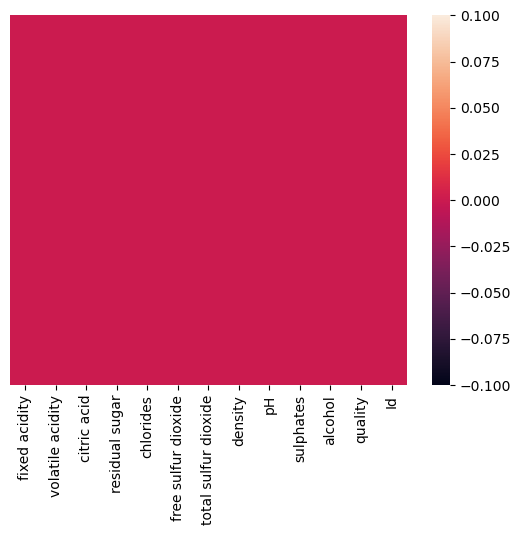

In [4]:
sns.heatmap(wineqt.isnull(),yticklabels=False)

#### No abnormalities so I will run the models

In [5]:
LRmodel = LogisticRegression()

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [7]:
LRmodel.fit(X_train,y_train)

C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### It gives us a warning, that we should scale the data, and it makes sense, as the citric acid is in the range of 10^(-2), while total sulphur dioxide is in the order of 10.
#### So we will use the StandardScaler to scale down the data 

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()

X_scale_train = scaler.fit_transform(X_train)
X_scale_test = scaler.transform(X_test)

LRmodel.fit(X_scale_train,y_train)
y_pred = LRmodel.predict(X_scale_test)

In [10]:
cm = confusion_matrix(y_test,y_pred)
prec_score = precision_score(y_test,y_pred,average='weighted')
f1Score = f1_score(y_test,y_pred,average='weighted')
recallScore = recall_score(y_test,y_pred,average='weighted')

C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
print(cm,prec_score,f1Score,recallScore,sep='\n')

[[  0   0   0   0   0   0]
 [  0   0   6   3   0   0]
 [  1   0 107  34   1   0]
 [  0   0  47  90   9   0]
 [  0   0   3  23  15   0]
 [  0   0   0   2   2   0]]
0.5921175272390734
0.6014072615303712
0.6180758017492711


#### As we can see the columns 1,2 and 6 are all zeroes, and the precision are very low, around 56 to 58 percent

#### So we will now use a more complex algorithm, to see if it can classify better. We will use RandomForestClassifier

In [12]:
RandForClass = RandomForestClassifier()

#### We will first use the train_test_split, only to train and test the RandomForestClassifier 

In [13]:
RandForClass.fit(X_scale_train,y_train)
y_pred = RandForClass.predict(X_scale_test)

In [14]:
cm = confusion_matrix(y_test,y_pred)
prec_score = precision_score(y_test,y_pred,average='weighted')
f1Score = f1_score(y_test,y_pred,average='weighted')
recallScore = recall_score(y_test,y_pred,average='weighted')

C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
print(cm,prec_score,f1Score,recallScore,sep='\n')

[[  0   6   3   0   0]
 [  0 111  30   2   0]
 [  0  49  90   7   0]
 [  0   1  17  23   0]
 [  0   0   2   1   1]]
0.6418626036005247
0.643565417199387
0.6559766763848397


#### As we can see, the accuracies have went up by 5 to 6 percent, to 61 to 64 percent. However this still is not great
#### It can happen, that there are biased data, so to handle it better we will use Stratified K fold cross validation

In [16]:
from sklearn.model_selection import StratifiedKFold

In [17]:
skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

In [18]:
cm_list,prec_scores,f1_scores,recall_scores=([],[],[],[])

In [19]:
for train_index,test_index in skf.split(X,y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    RandForClass.fit(X_train,y_train)
    y_pred = RandForClass.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)
    prec_score = precision_score(y_test,y_pred,average='weighted')
    f1Score = f1_score(y_test,y_pred,average='weighted')
    recallScore = recall_score(y_test,y_pred,average='weighted')    

    cm_list.append(cm)
    prec_scores.append(prec_score)
    f1_scores.append(f1Score)
    recall_scores.append(recallScore)

C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C

In [20]:
total_cm = sum(cm_list)
print(total_cm)

[[  0   0   5   1   0   0]
 [  0   0  23   9   1   0]
 [  0   0 359 116   8   0]
 [  0   0 115 320  26   1]
 [  0   0   6  61  74   2]
 [  0   0   0   4  10   2]]


In [21]:
print("Average Precision:",sum(prec_scores)/len(prec_scores))
print("Average f1-scores:",sum(f1_scores)/len(f1_scores))
print("Average recall_scores:",sum(recall_scores)/len(recall_scores))

Average Precision: 0.6338266061616467
Average f1-scores: 0.6448191203091269
Average recall_scores: 0.6605684516969279


#### Again our scores did improve, but this time only by a very little amount: 1-2 percent

#### Now we will use xgboost, which trains one tree after the other to correct the errors 

#### But for xgboost, there are a lot of parameters, and so we would need to use Hyperparameter Optimization, which we will do using RandomizedSearchCV

In [22]:
from sklearn.model_selection import RandomizedSearchCV

In [23]:
params = {
    "max_depth" : [3,5,7,9],
    "min_child_weight":[1,3,5,10],
    "gamma":[0,0.1,0.2,0.4],
    "subsample":[0.6,0.8,1.0],
    "colsample_bytree":[0.6,0.8,1.0],
    "reg_alpha":[0,0.1,1.0,10.0],
    "reg_lambda":[1.0,2.0,5.0],
    "learning_rate":[0.01,0.05,0.1]
}

In [24]:
classifier = xgboost.XGBClassifier()

random_search = RandomizedSearchCV(classifier, param_distributions=params,n_iter=20,verbose=3,cv=5,n_jobs=-1,scoring='roc_auc_ovr_weighted',random_state=42)

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc_ovr_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
print(random_search.best_params_)

{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.6}


In [28]:
    classifier = xgboost.XGBClassifier(subsample=1.0,reg_lambda=1.0,reg_alpha=0.1,min_child_weight=1,max_depth=9,learning_rate=0.1,gamma=0.2,colsample_bytree=0.6)

In [29]:
cm_list,prec_scores,f1_scores,recall_scores = ([],[],[],[])

In [30]:
for train_index, test_index in skf.split(X,y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train=y.iloc[train_index]
    y_test=y.iloc[test_index]

    classifier.fit(X_train,y_train)
    y_pred = classifier.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)
    prec_score = precision_score(y_test,y_pred,average='weighted')
    f1Score = f1_score(y_test,y_pred,average='weighted')
    recallScore = recall_score(y_test,y_pred,average='weighted')    

    cm_list.append(cm)
    prec_scores.append(prec_score)
    f1_scores.append(f1Score)
    recall_scores.append(recallScore)    

C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C

In [31]:
total_cm = sum(cm_list)
print(total_cm)

[[  0   0   5   1   0   0]
 [  0   0  24   8   1   0]
 [  0   1 362 112   8   0]
 [  0   0 122 313  26   1]
 [  0   0   8  62  71   2]
 [  0   0   1   7   6   2]]


In [32]:
print("Average Precision:",sum(prec_scores)/len(prec_scores))
print("Average f1-scores:",sum(f1_scores)/len(f1_scores))
print("Average recall_scores:",sum(recall_scores)/len(recall_scores))

Average Precision: 0.6286365219613237
Average f1-scores: 0.6382991053991692
Average recall_scores: 0.6544357618938175


#### Also we used stratified K fold to improve on our efficiencies, because it splits the data into training and testing set as such that it maintains the bias already present in the dataset. So if there were 60 percent yes, and 40 percent no, it will divide the data such that it always  maintains the same amount of percentage of bias. And it asks for how many number of time should the data be split, like we put n_iters=5 here, so it will divide the data into 5 blocks, and then in the first iteration, it will take the first block as testing, in which it will assign values as such that the bias is maintained, and then after the first iteration, it will take the second block of data as the testing dataset, and then repeat for all the blocks. However in test_train_split(), it directly takes some random block of data for training(the amount of data is the percentage we specify), so there is a high probability, that it might be very baised on either extremes, or might not be biased enough

#### Secondly, at the start, I did y = wineqt[:,:-2] -3. I subtracted the 3 because later on the xgboost it was throwing error saying that it expected [0,1,2,3..] but it got [3,4,5,...]

In [33]:
classifier = xgboost.XGBClassifier()

random_search = RandomizedSearchCV(classifier, param_distributions=params,n_iter=20,verbose=3,cv=5,n_jobs=-1,scoring='roc_auc_ovr_weighted',random_state=42)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc_ovr_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [34]:
print(random_search.best_params_)

{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.6}


In [35]:
classifier = xgboost.XGBClassifier(subsample=1.0,reg_lambda=1.0,reg_alpha=0.1,min_child_weight=1,max_depth=9,learning_rate=0.1,gamma=0.2,colsample_bytree=0.6)

In [36]:
cm_list,prec_scores,f1_scores,recall_scores = ([],[],[],[])

for train_index, test_index in skf.split(X,y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train=y.iloc[train_index]
    y_test=y.iloc[test_index]

    classifier.fit(X_train,y_train)
    y_pred = classifier.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)
    prec_score = precision_score(y_test,y_pred,average='weighted')
    f1Score = f1_score(y_test,y_pred,average='weighted')
    recallScore = recall_score(y_test,y_pred,average='weighted')    

    cm_list.append(cm)
    prec_scores.append(prec_score)
    f1_scores.append(f1Score)
    recall_scores.append(recallScore)    

C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Pranav Agrawal\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C

In [37]:
total_cm = sum(cm_list)
print(total_cm)

[[  0   0   5   1   0   0]
 [  0   0  24   8   1   0]
 [  0   1 362 112   8   0]
 [  0   0 122 313  26   1]
 [  0   0   8  62  71   2]
 [  0   0   1   7   6   2]]


In [38]:
print("Average Precision:",sum(prec_scores)/len(prec_scores))
print("Average f1-scores:",sum(f1_scores)/len(f1_scores))
print("Average recall_scores:",sum(recall_scores)/len(recall_scores))

Average Precision: 0.6286365219613237
Average f1-scores: 0.6382991053991692
Average recall_scores: 0.6544357618938175
